In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
nav_df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

print(nav_df.head())
print(nav_df.columns)

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
Index(['amfi_code', 'date', 'nav'], dtype='str')


In [5]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

print(nav_df.dtypes)

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object


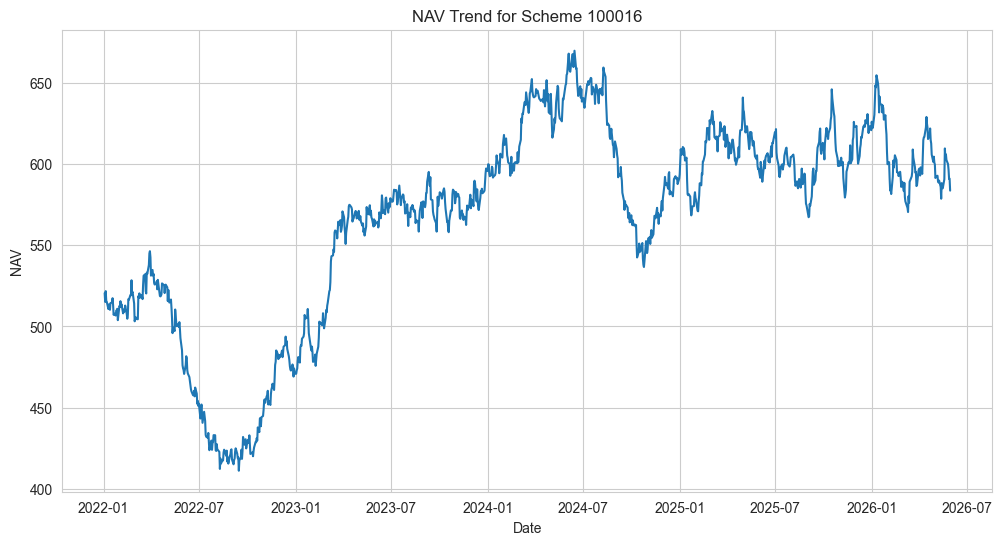

In [6]:
scheme_df = nav_df[nav_df["amfi_code"] == 100016]

plt.figure(figsize=(12,6))
plt.plot(scheme_df["date"], scheme_df["nav"])

plt.title("NAV Trend for Scheme 100016")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.show()


In [7]:
aum_df = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

print(aum_df.head())
print(aum_df.columns)

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


In [8]:
aum_df["date"] = pd.to_datetime(aum_df["date"])
aum_df["year"] = aum_df["date"].dt.year

print(aum_df.head())

        date           fund_house  aum_lakh_crore  aum_crore  num_schemes  \
0 2022-03-31      SBI Mutual Fund            6.05     605000          186   
1 2022-03-31  ICICI Prudential MF            4.65     465000          216   
2 2022-03-31     HDFC Mutual Fund            4.35     435000          195   
3 2022-03-31      Nippon India MF            2.70     270000          177   
4 2022-03-31    Kotak Mahindra MF            2.70     270000          168   

   year  
0  2022  
1  2022  
2  2022  
3  2022  
4  2022  


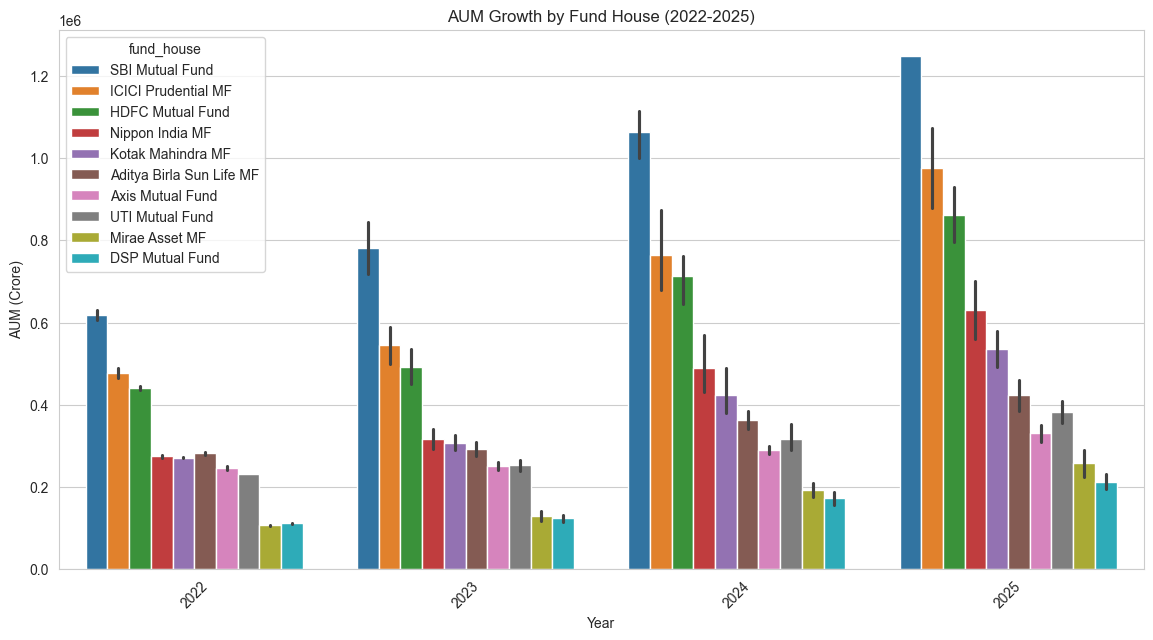

In [9]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum_df,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Crore)")
plt.xticks(rotation=45)

plt.show()

In [10]:
sip_df = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

print(sip_df.head())
print(sip_df.columns)

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


In [11]:
sip_df["month"] = pd.to_datetime(sip_df["month"])

print(sip_df.dtypes)

month                        datetime64[us]
sip_inflow_crore                      int64
active_sip_accounts_crore           float64
new_sip_accounts_lakh               float64
sip_aum_lakh_crore                  float64
yoy_growth_pct                      float64
dtype: object


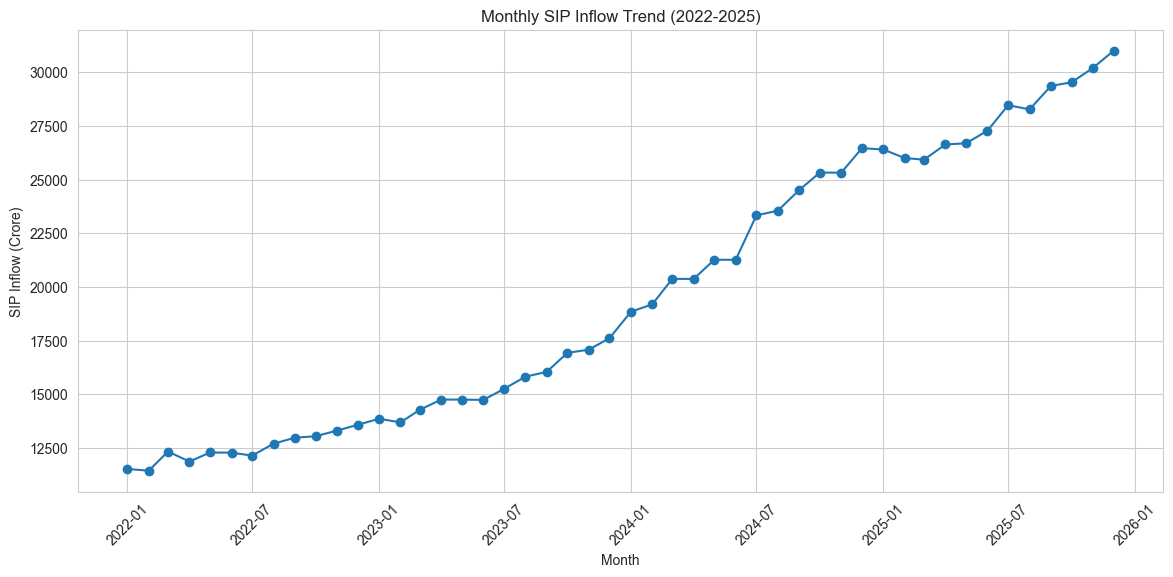

In [12]:
plt.figure(figsize=(14,6))

plt.plot(
    sip_df["month"],
    sip_df["sip_inflow_crore"],
    marker="o"
)

plt.title("Monthly SIP Inflow Trend (2022-2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.xticks(rotation=45)

plt.show()

In [13]:
max_row = sip_df.loc[sip_df["sip_inflow_crore"].idxmax()]

print(max_row)

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object


In [14]:
category_df = pd.read_csv("../data/raw/05_category_inflows.csv")

print(category_df.head())
print(category_df.columns)

     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0
Index(['month', 'category', 'net_inflow_crore'], dtype='str')


In [15]:
print(category_df.columns)

Index(['month', 'category', 'net_inflow_crore'], dtype='str')


In [16]:
category_df["month"] = pd.to_datetime(category_df["month"])

In [17]:
heatmap_df = category_df.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

print(heatmap_df.head())

month            2024-04-01  2024-05-01  2024-06-01  2024-07-01  2024-08-01  \
category                                                                      
ELSS                  466.0       553.0       472.0       471.0       499.0   
Flexi Cap            4947.0      5529.0      4478.0      4869.0      5562.0   
Gilt                  784.0       836.0       864.0       959.0       952.0   
Hybrid               2955.0      3487.0      3163.0      3291.0      3684.0   
Large & Mid Cap      4214.0      4368.0      4610.0      5023.0      5411.0   

month            2024-09-01  2024-10-01  2024-11-01  2024-12-01  2025-01-01  \
category                                                                      
ELSS                  537.0       537.0       571.0       521.0       516.0   
Flexi Cap            5397.0      6004.0      6111.0      4654.0      5603.0   
Gilt                  925.0       898.0       704.0       831.0       744.0   
Hybrid               3015.0      3314.0      3264.0

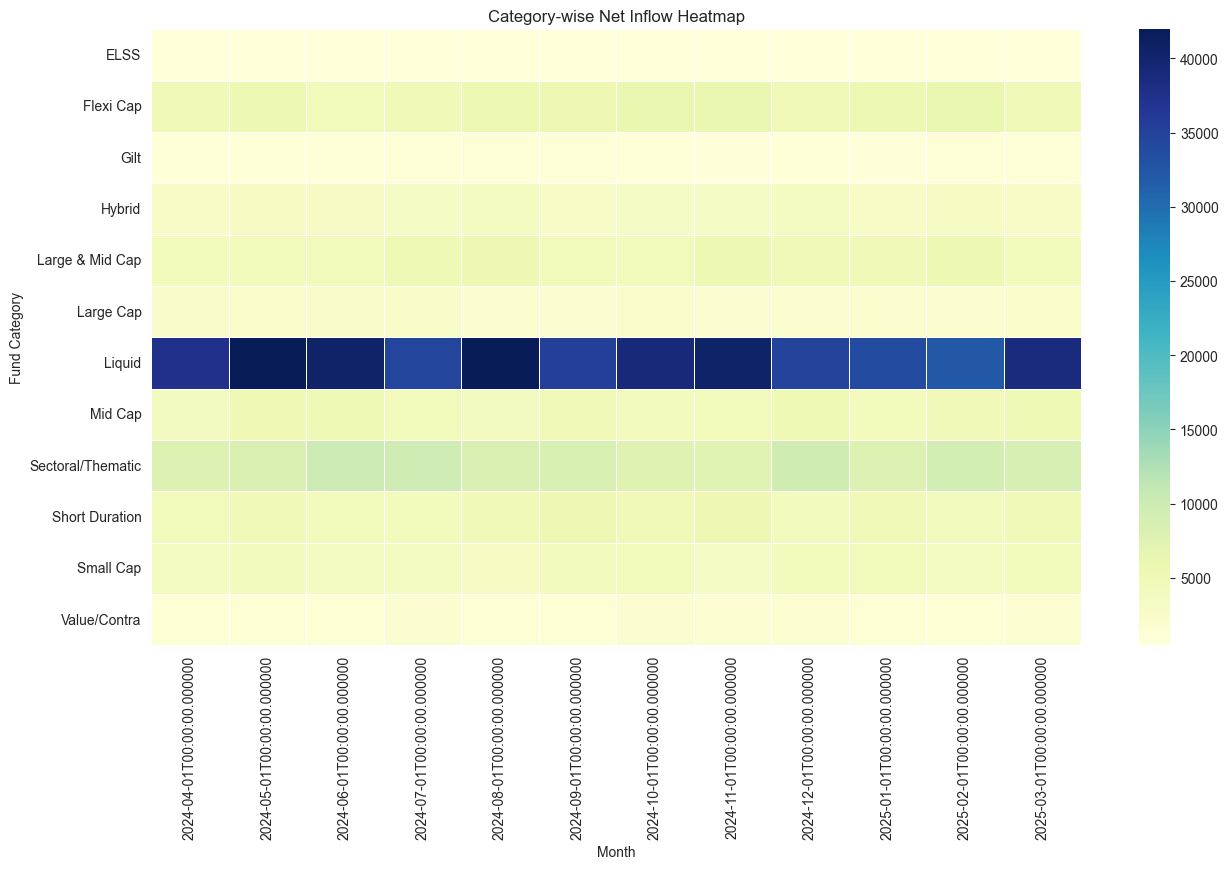

In [18]:
plt.figure(figsize=(15,8))

sns.heatmap(
    heatmap_df,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.show()

In [19]:
investor_df = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

print(investor_df.head())
print(investor_df.columns)

  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              Sip        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              Sip         912   
3   INV003436       2024-01-01     118634              Sip        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female                54.4   
4        Delhi      Noida       T30     26-35    Male                14.5   

  payment_mode kyc_status  
0          UPI   Verified  
1       Cheque   Verified  
2      M

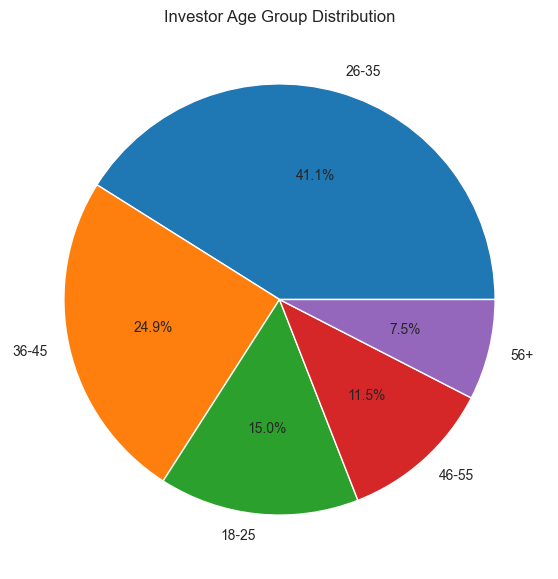

In [20]:
age_counts = investor_df["age_group"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.show()

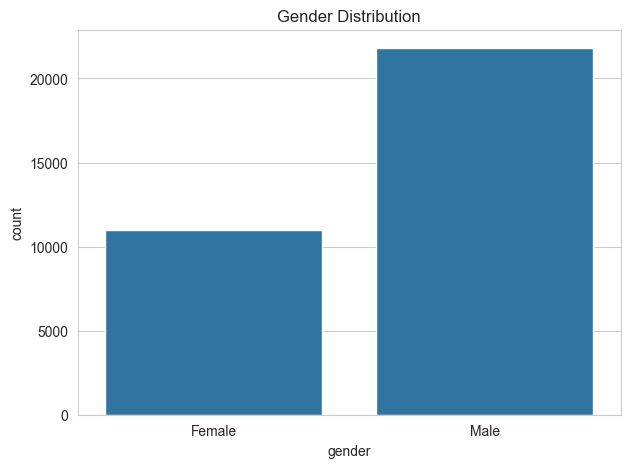

In [21]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=investor_df,
    x="gender"
)

plt.title("Gender Distribution")

plt.show()

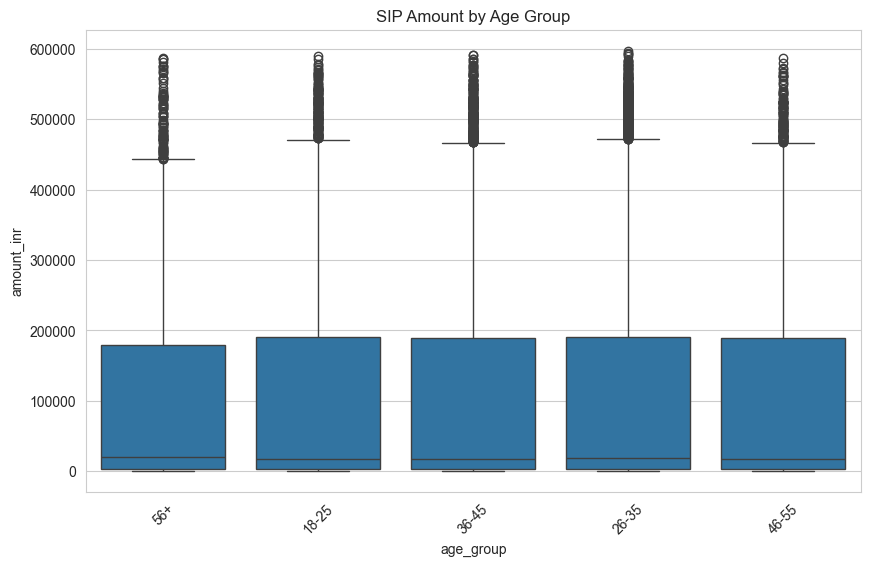

In [22]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor_df,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")

plt.xticks(rotation=45)

plt.show()

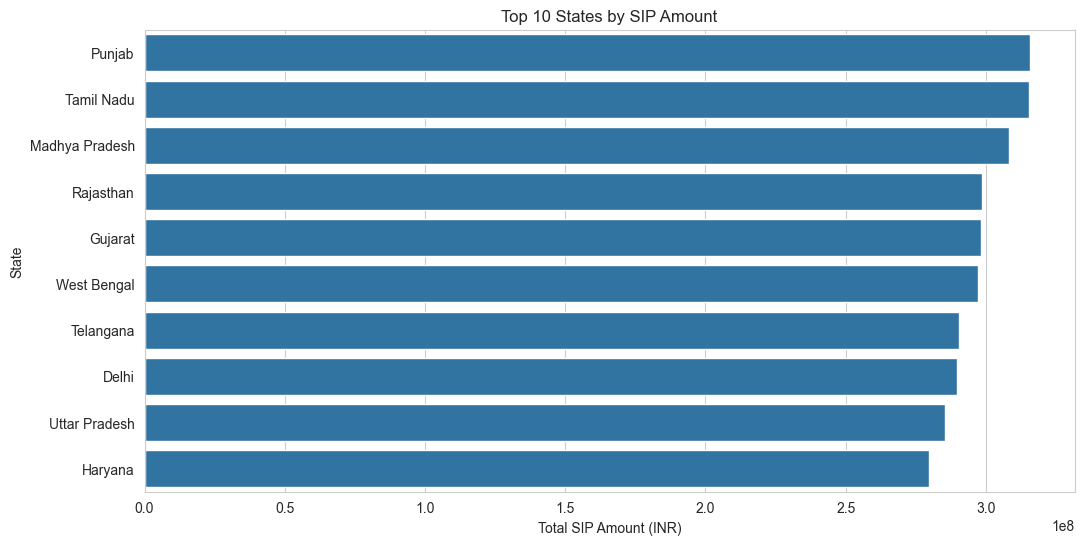

In [23]:
state_sip = investor_df.groupby("state")["amount_inr"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=state_sip.values, y=state_sip.index)

plt.title("Top 10 States by SIP Amount")
plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")

plt.show()

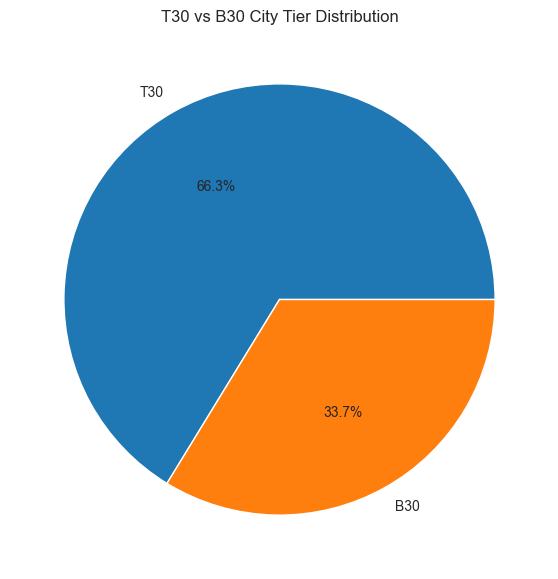

In [24]:
city_tier_counts = investor_df["city_tier"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    city_tier_counts,
    labels=city_tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 City Tier Distribution")
plt.show()

In [25]:
folio_df = pd.read_csv("../data/raw/06_industry_folio_count.csv")

print(folio_df.head())
print(folio_df.columns)

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')


In [26]:
folio_df["date"] = pd.to_datetime(folio_df["date"])

KeyError: 'date'

In [27]:
folio_df = pd.read_csv("../data/raw/06_industry_folio_count.csv")

print(folio_df.head())
print(folio_df.columns)

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')


In [28]:
folio_df["month"] = pd.to_datetime(folio_df["month"])

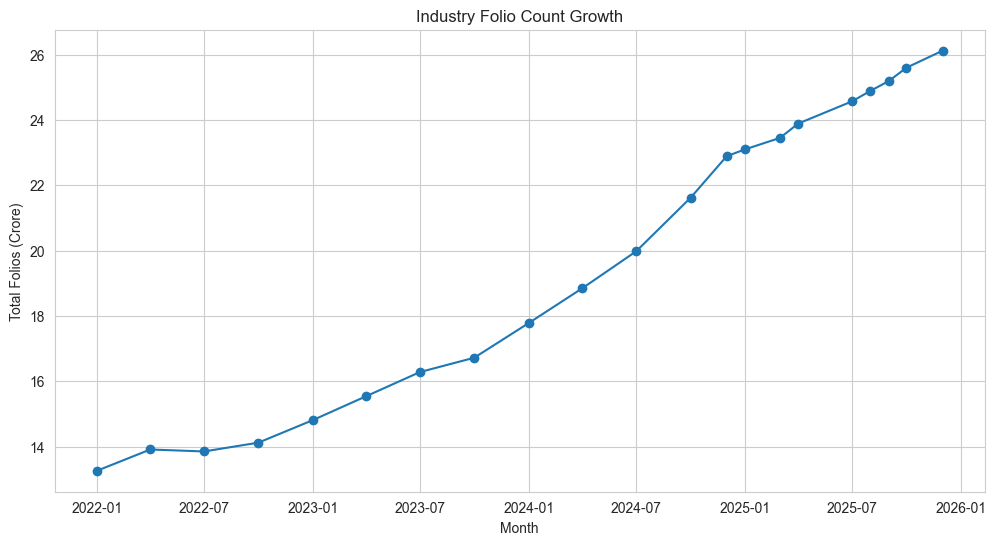

In [29]:
plt.figure(figsize=(12,6))

plt.plot(
    folio_df["month"],
    folio_df["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Count Growth")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.show()

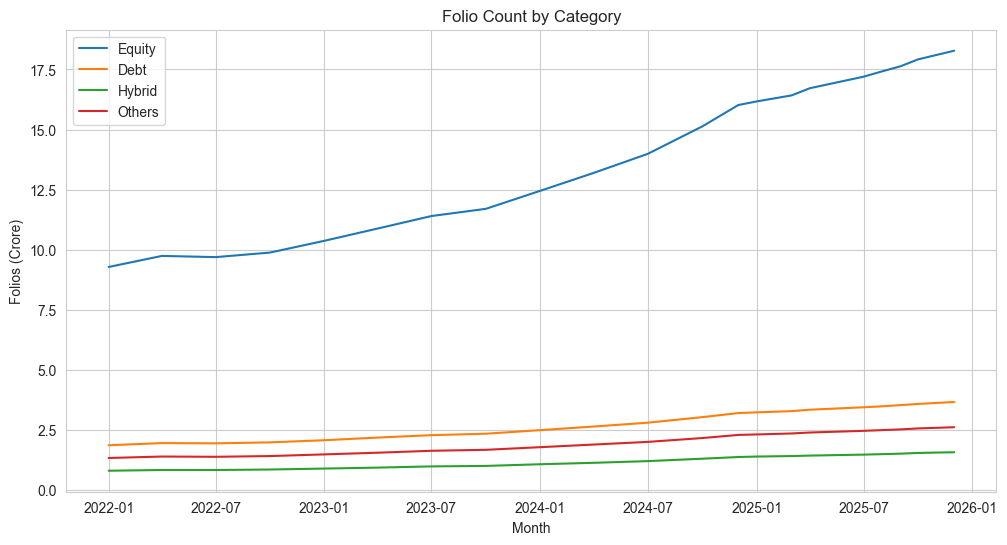

In [30]:
plt.figure(figsize=(12,6))

plt.plot(folio_df["month"], folio_df["equity_folios_crore"], label="Equity")
plt.plot(folio_df["month"], folio_df["debt_folios_crore"], label="Debt")
plt.plot(folio_df["month"], folio_df["hybrid_folios_crore"], label="Hybrid")
plt.plot(folio_df["month"], folio_df["others_folios_crore"], label="Others")

plt.title("Folio Count by Category")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")
plt.legend()

plt.show()

In [31]:
perf_df = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

print(perf_df.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


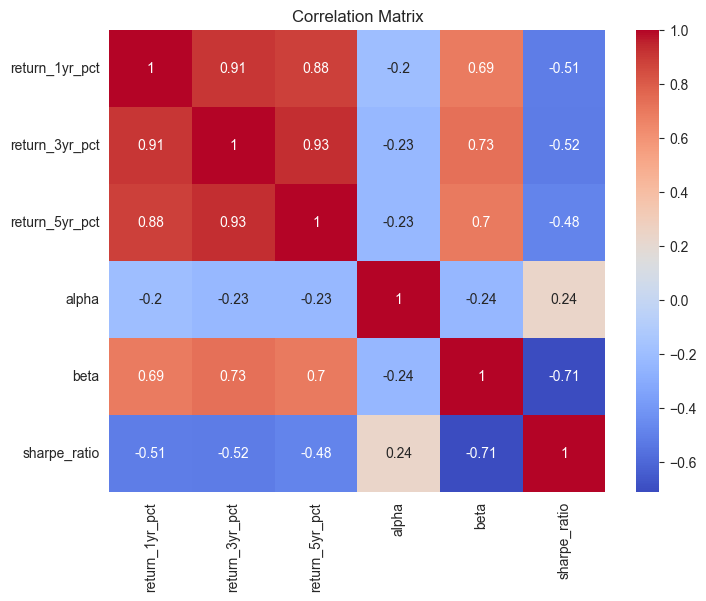

In [32]:
corr_cols = [
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct",
    "alpha",
    "beta",
    "sharpe_ratio"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    perf_df[corr_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [33]:
holdings_df = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print(holdings_df.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [34]:
holdings_df = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print(holdings_df.head())
print(holdings_df.columns)

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


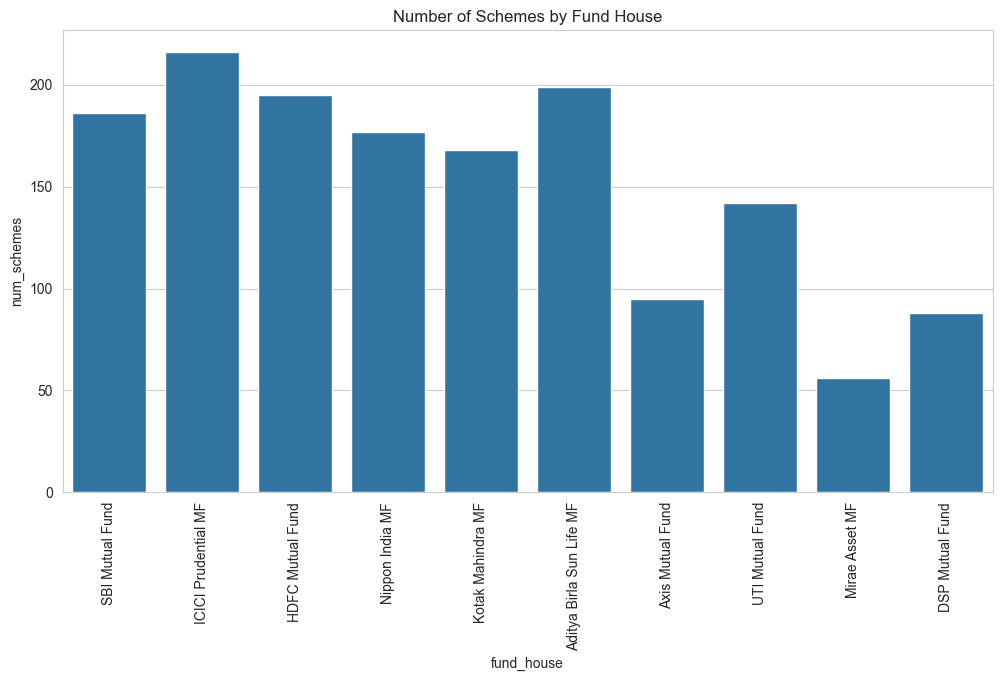

In [36]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum_df,
    x="fund_house",
    y="num_schemes"
)

plt.xticks(rotation=90)
plt.title("Number of Schemes by Fund House")

plt.show()

In [35]:
print(holdings_df.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


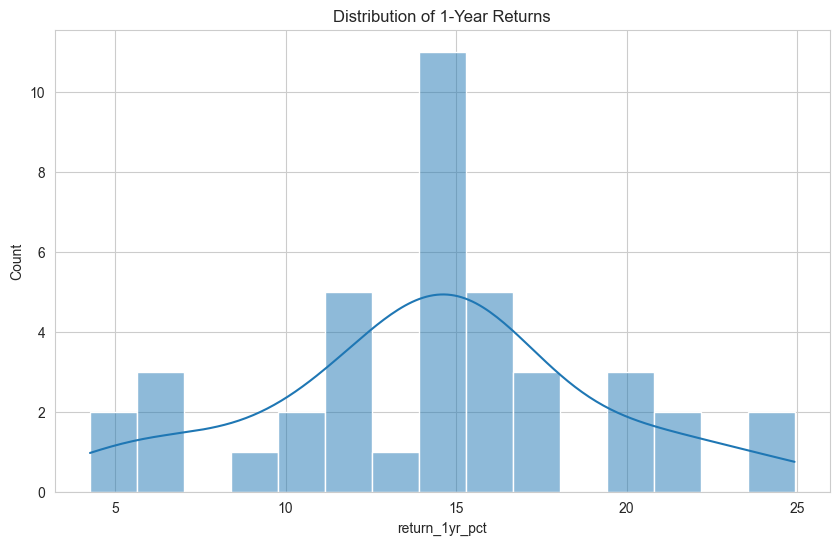

In [37]:
plt.figure(figsize=(10,6))

sns.histplot(
    perf_df["return_1yr_pct"],
    bins=15,
    kde=True
)

plt.title("Distribution of 1-Year Returns")

plt.show()

In [38]:
sector_df = holdings_df.groupby("sector")["weight_pct"].sum()

print(sector_df)

sector
Automobile        323.65
Banking           652.26
Cement            105.03
Consumer Goods    127.61
Diversified       169.23
Energy            117.91
FMCG              229.11
IT                455.47
Infrastructure    192.16
NBFC              119.09
Paints             89.86
Pharma            407.45
Telecom           145.62
Utilities         265.54
Name: weight_pct, dtype: float64


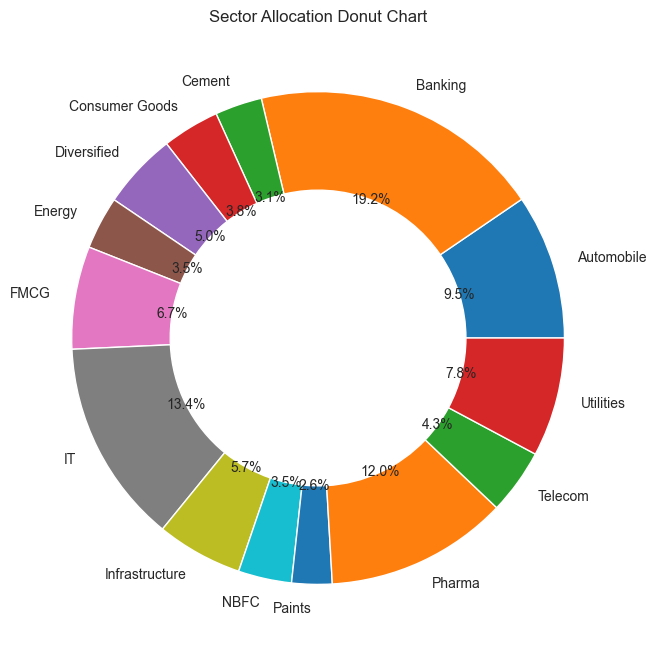

In [39]:
plt.figure(figsize=(8,8))

plt.pie(
    sector_df,
    labels=sector_df.index,
    autopct="%1.1f%%",
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation Donut Chart")

plt.show()